<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day02-tensors-and-a-first-class.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 2 — Programming in code: tensors, autograd, and a first class {.unnumbered}

The tensor/autograd sections below are reused directly from this course's own `notebooks/pytorch_bio_intro.ipynb` (only lightly trimmed) — no need to write this from scratch when it already existed and already uses a nice DNA-themed example. The exercises at the end are new, closing the loop with Day 1 and previewing Day 3.

# Day 2 — Programming Toolkit: NumPy/pandas/Matplotlib, Notebooks, Biopython, SciPy, scikit-learn, PyTorch

This notebook follows the book page in order: a quick NumPy/pandas/Matplotlib
recap, a real demonstration of why cell execution order matters, real
Biopython usage (a `Seq` object, `Bio.SeqIO`, and a live `Bio.Entrez`
fetch), a SciPy statistical test and a scikit-learn linear regression,
PyTorch tensors and autograd (reused from this course's own existing
material), opening a `.zip` archive, and finally the from-database-to-plot
worked example, plotted three times over.

In [1]:
# Section 1: Setup and installation checks
import torch, numpy as np, random, pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.5.1
CUDA available: True
Using device: cuda


## 1. NumPy, pandas, and Matplotlib: a quick recap

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=0)
n_genes = 50
lengths = rng.integers(100, 1000, size=n_genes)
gc_content = np.clip(0.3 + 0.0003 * lengths + rng.normal(0, 0.03, size=n_genes), 0, 1)

genes = pd.DataFrame({
    "name": [f"gene_{i}" for i in range(n_genes)],
    "length": lengths,
    "gc_content": gc_content,
})
print(genes.head())
print()
print(genes.describe())

     name  length  gc_content
0  gene_0     865    0.562320
1  gene_1     673    0.479595
2  gene_2     560    0.440348
3  gene_3     342    0.388868
4  gene_4     377    0.419706

           length  gc_content
count   50.000000   50.000000
mean   512.520000    0.460031
std    273.843635    0.089423
min    102.000000    0.265995
25%    257.250000    0.385970
50%    566.500000    0.462944
75%    703.000000    0.532858
max    973.000000    0.636703


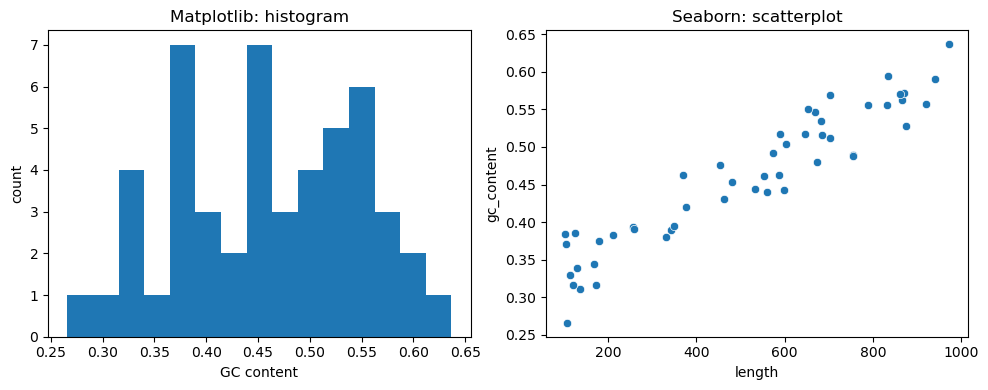

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(genes["gc_content"], bins=15)
axes[0].set_xlabel("GC content"); axes[0].set_ylabel("count")
axes[0].set_title("Matplotlib: histogram")
sns.scatterplot(data=genes, x="length", y="gc_content", ax=axes[1])
axes[1].set_title("Seaborn: scatterplot")
fig.tight_layout()
plt.show()

## 2. What notebooks are for: a real cell-order demonstration

Run the cell below, then run it again (and again) without re-running the
cell above it that sets `counter = 0`. The printed value keeps climbing —
`counter` is *not* reset by re-running "the same" cell, because the
variable lives in the notebook's memory, not on the page. This is the
exact mechanism behind the "stale value" gotcha described on the book
page: whatever a cell prints reflects the *last time it (and everything
it depends on) was actually run*, not its position on the page.

In [4]:
counter = 0
print(counter)

0


In [5]:
counter += 1
print("counter is now:", counter)
# Re-run THIS cell a few times (Shift+Enter repeatedly) without re-running
# the cell above -- the number keeps climbing. Then use "Restart and run
# all" and watch it reset to 1: that's the only way to be sure a notebook's
# state matches what's written on the page.

counter is now: 1


## 3. Biopython: sequences and databases

A real 30-nucleotide fragment of human beta-globin (*HBB*), fetched live
from NCBI (accession `NM_000518.5`) while writing this notebook.

In [6]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

# The first 10 codons of HBB's real coding sequence (NM_000518.5),
# fetched live via Bio.Entrez while writing this notebook.
bio_seq = Seq("ATGGTGCATCTGACTCCTGAGGAGAAGTCT")

print("sequence:           ", bio_seq)
print("length:              ", len(bio_seq))
print("GC fraction:         ", gc_fraction(bio_seq))
print("reverse complement:  ", bio_seq.reverse_complement())
print("translated (codons):", bio_seq.translate())

sequence:            ATGGTGCATCTGACTCCTGAGGAGAAGTCT
length:               30
GC fraction:          0.5
reverse complement:   AGACTTCTCCTCAGGAGTCAGATGCACCAT
translated (codons): MVHLTPEEKS


### `Bio.SeqIO`: parsing a FASTA file, not just one sequence

A single `Seq` object is the building block; real work means parsing a
*file* of them. `Bio.SeqIO` does that regardless of format (FASTA here,
but the same call works for GenBank, and more) — this is exactly the
mechanism Day 3's database work builds on, just applied there to files
fetched live from NCBI/UniProt instead of a small local example.

In [7]:
from io import StringIO
from Bio import SeqIO

# A tiny two-record FASTA file, in memory (Bio.SeqIO works identically
# on a real file opened from disk -- StringIO just avoids writing one
# to disk for this small example).
fasta_text = """>HBB_fragment human beta-globin, first 10 codons (NM_000518.5)
ATGGTGCATCTGACTCCTGAGGAGAAGTCT
>toy_second_record a second, unrelated toy sequence
TTTTAAATTTAAATTT
"""

records = list(SeqIO.parse(StringIO(fasta_text), "fasta"))
print(f"parsed {len(records)} records:")
for rec in records:
    print(f"  {rec.id}: length {len(rec.seq)}, GC fraction {gc_fraction(rec.seq):.2f}")

parsed 2 records:
  HBB_fragment: length 30, GC fraction 0.50
  toy_second_record: length 16, GC fraction 0.00


### `Bio.Entrez`: actually reaching NCBI

The examples above used a sequence already typed in. `Bio.Entrez` is how
you get it live, over the network, straight from NCBI — this is the real
mechanism Day 3's database work uses at full scale.

In [8]:
from Bio import Entrez, SeqIO

Entrez.email = "arne@bioinfo.se"  # NCBI asks for a real contact email on every request

handle = Entrez.efetch(db="nuccore", id="NM_000518.5", rettype="gb", retmode="text")
hbb_record = SeqIO.read(handle, "genbank")
handle.close()

print("id:         ", hbb_record.id)
print("description:", hbb_record.description)
print("length:     ", len(hbb_record.seq))

id:          NM_000518.5
description: Homo sapiens hemoglobin subunit beta (HBB), mRNA
length:      628


## 4. SciPy: for statistics

`scipy.stats.pearsonr` checks whether the length/GC-content relationship
from section 1 is statistically significant. `scipy.stats.ttest_ind` —
used later in this notebook's closing example — is the same Student's
t-test Day 1 worked through by hand.

In [9]:
from scipy import stats

r, p_value = stats.pearsonr(genes["length"], genes["gc_content"])
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

Pearson r = 0.944, p = 9.78e-25


## 5. scikit-learn

Day 6 builds a linear model "by hand" with raw tensors and gradient
descent, precisely to see the mechanics. In practice, for a plain linear
regression like this one, you would normally reach for scikit-learn's
ready-made implementation instead.

In [10]:
from sklearn.linear_model import LinearRegression

X = genes[["length"]]  # scikit-learn expects a 2D array of features
y = genes["gc_content"]

model = LinearRegression()
model.fit(X, y)

print("slope (per base):", model.coef_[0])
print("intercept:        ", model.intercept_)
print("R^2 on training data:", model.score(X, y))
print("(ground truth used to generate the data: slope=0.0003, intercept=0.3)")

slope (per base): 0.0003082228065033034
intercept:         0.3020608547966878
R^2 on training data: 0.8909068712829619
(ground truth used to generate the data: slope=0.0003, intercept=0.3)


## 6. PyTorch: tensors, creation, shapes, and dtypes

In [11]:
# Small DNA example: 4 samples, 8 bases each encoded as ints 0-3
bases = np.array([
    [0,1,2,3,0,1,2,3],
    [3,3,2,2,1,1,0,0],
    [1,0,1,0,2,2,3,3],
    [2,2,1,1,0,0,3,3],
], dtype=np.int64)

tensor_from_np = torch.tensor(bases)                 # infers dtype/int64
float_tensor = torch.tensor(bases, dtype=torch.float32)
zeros = torch.zeros((2,3), dtype=torch.float32)
ones  = torch.ones((2,3), dtype=torch.float32)
rand  = torch.rand((2,3), dtype=torch.float32)

print("tensor_from_np:", tensor_from_np.shape, tensor_from_np.dtype)
print("float_tensor :", float_tensor.shape, float_tensor.dtype)
print("zeros shape   :", zeros.shape, "ones shape:", ones.shape, "rand shape:", rand.shape)

tensor_from_np: torch.Size([4, 8]) torch.int64
float_tensor : torch.Size([4, 8]) torch.float32
zeros shape   : torch.Size([2, 3]) ones shape: torch.Size([2, 3]) rand shape: torch.Size([2, 3])


### Basic tensor operations (indexing, slicing, reshaping)

In [12]:
data = float_tensor  # from earlier cell

first_two_samples = data[:2, :]          # slicing
first_four_features = data[:, :4]
reshaped = data.view(2, 2, 8)             # reshape into (batch, chunk, features)
concat = torch.cat([data, data], dim=0)   # stack samples

print("First two samples:\n", first_two_samples)
print("First four features of all samples:\n", first_four_features)
print("Reshaped (2,2,8):", reshaped.shape)
print("Concatenated shape:", concat.shape)

# Elementwise operations
mean_per_feature = data.mean(dim=0)
std_per_feature  = data.std(dim=0)
print("Feature means:", mean_per_feature)
print("Feature stds :", std_per_feature)

First two samples:
 tensor([[0., 1., 2., 3., 0., 1., 2., 3.],
        [3., 3., 2., 2., 1., 1., 0., 0.]])
First four features of all samples:
 tensor([[0., 1., 2., 3.],
        [3., 3., 2., 2.],
        [1., 0., 1., 0.],
        [2., 2., 1., 1.]])
Reshaped (2,2,8): torch.Size([2, 2, 8])
Concatenated shape: torch.Size([8, 8])
Feature means: tensor([1.5000, 1.5000, 1.5000, 1.5000, 0.7500, 1.0000, 2.0000, 2.2500])
Feature stds : tensor([1.2910, 1.2910, 0.5774, 1.2910, 0.9574, 0.8165, 1.4142, 1.5000])


### Autograd: gradients on simple functions

In [13]:
x = torch.linspace(-2, 2, steps=5, requires_grad=True)
y = (x**2).mean()  # simple function
print("y:", y.item())

y.backward()       # compute dy/dx
print("dy/dx:", x.grad)

y: 2.0
dy/dx: tensor([-0.8000, -0.4000,  0.0000,  0.4000,  0.8000])


## 6. Closing the loop with Day 1

Day 1's practice problems were done entirely by hand. Here they are again, this time in code — confirm you get the same answers.

In [14]:
import torch

# Day 1, practice problem 1: (2, -1, 3) . (1, 4, 0)
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
print("dot product:", torch.dot(a, b).item(), " (Day 1 answer: -2)")

# Day 1, practice problem 2: gradient of f(x0, x1) = 3*x0**2 + 2*x0*x1 at (1, 2)
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3*x0**2 + 2*x0*x1
f.backward()
print("gradient:", (x0.grad.item(), x1.grad.item()), " (Day 1 answer: (10, 2))")

dot product: -2.0  (Day 1 answer: -2)
gradient: (10.0, 2.0)  (Day 1 answer: (10, 2))


## 12. Opening zip archives

Downloaded datasets -- including this course's own capstone project data
-- routinely arrive as a single `.zip` file holding many files inside.
The standard-library `zipfile` module opens, lists, and extracts one
without any separate unzip program. This example builds a small zip
archive first (so the example is self-contained), then does exactly what
you'd do with a real downloaded one: list what's inside, then extract
it.

In [15]:
import zipfile
from pathlib import Path

# Build a small zip archive to demonstrate on (a real downloaded dataset
# already has one -- this just avoids depending on a network download
# for this example).
demo_dir = Path("zip_demo")
demo_dir.mkdir(exist_ok=True)
zip_path = demo_dir / "example_dataset.zip"

with zipfile.ZipFile(zip_path, "w") as zf:
    zf.writestr("dataset/seq1.fasta", ">seq1\nATGGTGCATCTGACTCCTGAG\n")
    zf.writestr("dataset/seq2.fasta", ">seq2\nTTTTAAATTTAAATTT\n")
    zf.writestr("dataset/readme.txt", "Two toy FASTA files.\n")

# --- This is the part that matters: opening someone else's zip file ---
with zipfile.ZipFile(zip_path) as zf:
    print("Contents of the archive:")
    for name in zf.namelist():
        print(" ", name)

    extract_dir = demo_dir / "extracted"
    zf.extractall(extract_dir)
    print()
    print(f"Extracted to {extract_dir}/:")
    for p in sorted(extract_dir.rglob("*")):
        if p.is_file():
            print(" ", p.relative_to(extract_dir))

# Clean up so re-running this cell (or the whole notebook) stays tidy.
import shutil
shutil.rmtree(demo_dir)

Contents of the archive:
  dataset/seq1.fasta
  dataset/seq2.fasta
  dataset/readme.txt

Extracted to zip_demo/extracted/:
  dataset/readme.txt
  dataset/seq1.fasta
  dataset/seq2.fasta


## 8. Putting it together: from database to plot

**Step 1 — Biopython, for real data**: five real human globin genes,
fetched live from NCBI.

In [16]:
from Bio import Entrez, SeqIO

Entrez.email = "arne@bioinfo.se"

gene_accessions = {
    "HBB": "NM_000518.5",
    "HBA1": "NM_000558.5",
    "HBA2": "NM_000517.6",
    "MB": "NM_001382809.1",
    "NGB": "NM_021257.4",
}

records = {}
for symbol, acc in gene_accessions.items():
    handle = Entrez.efetch(db="nuccore", id=acc, rettype="gb", retmode="text")
    records[symbol] = SeqIO.read(handle, "genbank")
    handle.close()
    print(f"{symbol:5s} {acc:18s} length={len(records[symbol].seq):5d}  {records[symbol].description}")

HBB   NM_000518.5        length=  628  Homo sapiens hemoglobin subunit beta (HBB), mRNA


HBA1  NM_000558.5        length=  577  Homo sapiens hemoglobin subunit alpha 1 (HBA1), mRNA


HBA2  NM_000517.6        length=  576  Homo sapiens hemoglobin subunit alpha 2 (HBA2), mRNA


MB    NM_001382809.1     length= 1286  Homo sapiens myoglobin (MB), transcript variant 5, mRNA


NGB   NM_021257.4        length= 1778  Homo sapiens neuroglobin (NGB), mRNA


**Step 2 — SciPy + Matplotlib, honestly labeled as simulated.** NCBI
doesn't hand you a differential-expression experiment for five genes on
demand, so from here on the *expression values* are simulated, not real
measurements — same honesty split as Day 1's own volcano plot. *HBB*
alone is given a real simulated effect; the other four are left at
(noisy) baseline. `scipy.stats.ttest_ind` gives each gene a p-value from
4 control vs. 4 treatment replicates (matching Day 1's own t-test worked
example).

In [17]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(2)
n_replicates = 4

# Illustrative baseline log2 expression levels and true simulated fold
# changes -- NOT real measurements. Only HBB is given a real effect.
baseline_expr = {"HBB": 10.0, "HBA1": 9.5, "HBA2": 9.3, "MB": 6.0, "NGB": 3.0}
true_log2fc =    {"HBB": 2.0,  "HBA1": 0.1, "HBA2": -0.05, "MB": 0.0, "NGB": 0.15}

results = []
for symbol in gene_accessions:
    control = rng.normal(baseline_expr[symbol], 0.4, size=n_replicates)
    treatment = rng.normal(baseline_expr[symbol] + true_log2fc[symbol], 0.4, size=n_replicates)
    t_stat, p_value = stats.ttest_ind(control, treatment)
    observed_log2fc = treatment.mean() - control.mean()
    results.append((symbol, observed_log2fc, p_value))
    print(f"{symbol:5s} log2FC={observed_log2fc:+.3f}  p={p_value:.5f}  -log10(p)={-np.log10(p_value):.3f}")

HBB   log2FC=+2.658  p=0.00009  -log10(p)=4.029
HBA1  log2FC=-0.016  p=0.92887  -log10(p)=0.032
HBA2  log2FC=+0.210  p=0.19409  -log10(p)=0.712
MB    log2FC=-0.245  p=0.58033  -log10(p)=0.236
NGB   log2FC=-0.165  p=0.40563  -log10(p)=0.392


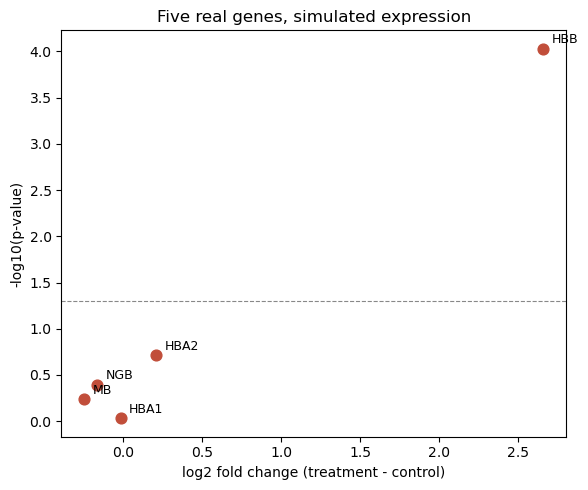

In [18]:
import matplotlib.pyplot as plt

symbols = [r[0] for r in results]
log2fcs = np.array([r[1] for r in results])
pvalues = np.array([r[2] for r in results])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(log2fcs, -np.log10(pvalues), s=60, color="#c14e3a")
for sym, x, y in zip(symbols, log2fcs, -np.log10(pvalues)):
    ax.annotate(sym, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(-np.log10(0.05), color="#888", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold change (treatment - control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Five real genes, simulated expression")
fig.tight_layout()
plt.show()

**Step 3 — the notebook payoff.** Re-run the same plot with a different
color scheme:

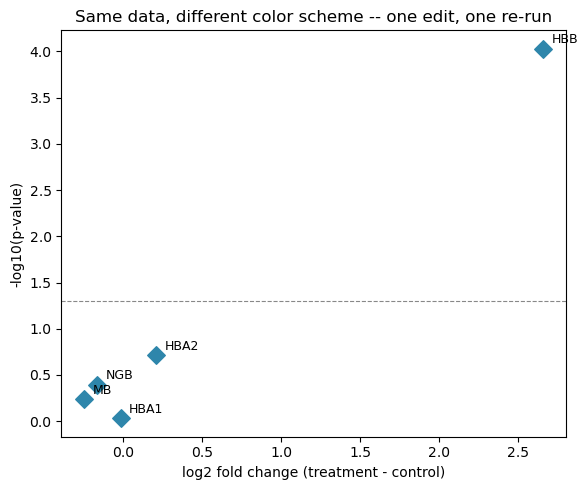

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(log2fcs, -np.log10(pvalues), s=80, color="#2e86ab", marker="D")
for sym, x, y in zip(symbols, log2fcs, -np.log10(pvalues)):
    ax.annotate(sym, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(-np.log10(0.05), color="#888", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold change (treatment - control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Same data, different color scheme -- one edit, one re-run")
fig.tight_layout()
plt.show()

And highlighting *HBB* specifically:

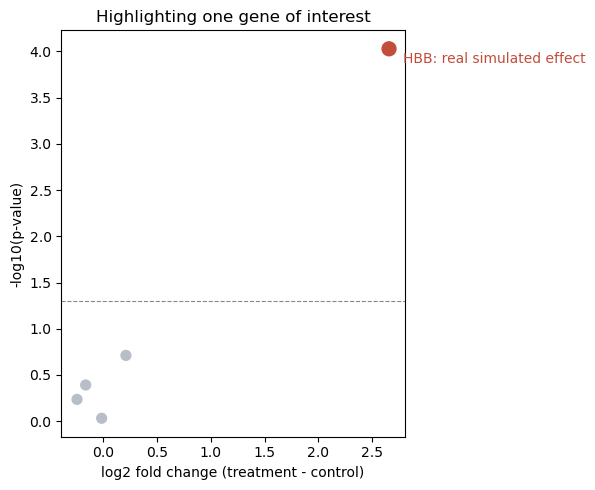

Three plots, three small edits, three re-runs -- no rebuild from scratch.


In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#c14e3a" if sym == "HBB" else "#b8bec8" for sym in symbols]
sizes = [100 if sym == "HBB" else 50 for sym in symbols]
ax.scatter(log2fcs, -np.log10(pvalues), s=sizes, color=colors)
ax.annotate("HBB: real simulated effect", (log2fcs[0], -np.log10(pvalues[0])),
            textcoords="offset points", xytext=(10, -10), fontsize=10, color="#c14e3a")
ax.axhline(-np.log10(0.05), color="#888", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold change (treatment - control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Highlighting one gene of interest")
fig.tight_layout()
plt.show()

print("Three plots, three small edits, three re-runs -- no rebuild from scratch.")

## Try it yourself

Pick a different real gene (any valid RefSeq accession), fetch it with
`Bio.Entrez` the same way, and add it to the volcano-plot example above.